In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

In [ ]:
# CONTROLLO DELLA FORMA DEI DATI
# 2. Guarda quali file ci sono dentro la cartella scaricata
print("File disponibili:", os.listdir(path))
# I file sono: 'DailyDelhiClimateTrain.csv' e 'DailyDelhiClimateTest.csv'

# 3. Carico il CSV di train con Pandas
csv_path = os.path.join(path, "DailyDelhiClimateTrain.csv")
df = pd.read_csv(csv_path)

print(df.head())

In [ ]:
# 4. ESTRAZIONE FEATURES
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure'] # le intestazioni che saranno le classi
X_train_raw = df[features].values            # Tutte e 4 le variabili
y_train_raw = df[['meantemp']].values # solo la temperatura

print("Forma Input:", X_train_raw.shape)
print("Forma Target:", y_train_raw.shape)

Forma Input: (1462, 4)
Forma Target: (1462, 1)


In [ ]:
# 5. NORMALIZZAZIONE
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Addestriamo i due scaler separatamente
X_scaled = scaler_X.fit_transform(X_train_raw) # valori numerici
y_scaled = scaler_y.fit_transform(y_train_raw) # Solo la temperatura

In [ ]:
# 6. PREPARAZIONE DATI PER PREVISIONE

WINDOW_SIZE = 7  # Es. gli ultimi 7 giorni per prevedere il futuro

# 1. Il Target (y) in questo caso non sono le etichette ma la temperatura da prevedere (colonna 'meantemp', che era l'indice 0)
# ma dobbiamo farlo partire dal giorno 7 (ossia dopo la prima finestra)!
# perchè lui associa 1 target/etichetta (temperatura) a 1 finestra (sequenza di 7 giorni)
target_col = 0 # 'meantemp' è la prima colonna
targets = y_scaled[WINDOW_SIZE:, target_col]

# 1. Tronchiamo X_scaled in modo che abbia la stessa lunghezza dei targets
# (togliamo gli ultimi 7 giorni in fondo che non avrebbero un giorno futuro da prevedere)
inputs = X_scaled[:-WINDOW_SIZE]

print("Lunghezza Input:", len(inputs))
print("Lunghezza Target:", len(targets))

Lunghezza Input: 1455
Lunghezza Target: 1455


In [ ]:
# CREAZIONE BATCH DI TRAINING
BATCH_SIZE = 32

dataset = keras.utils.timeseries_dataset_from_array(
    data=inputs,
    targets=targets,               # <--- Ora gli diciamo qual è la risposta corretta!
    sequence_length=WINDOW_SIZE,   # 7 giorni
    sequence_stride=1,
    batch_size=BATCH_SIZE
)

# Verifichiamo cosa c'è dentro un batch!
for x_batch, y_batch in dataset.take(1):
    print("Forma Input (x_batch):", x_batch.shape)   # (32, 7, 4) -> 32 finestre di 7 giorni x 4 variabili
    print("Forma Target (y_batch):", y_batch.shape)  # (32,)      -> Le 32 temperature reali del giorno dopo

In [ ]:
# MODELLO
model = keras.Sequential([
    # Input Layer: (7 giorni, 4 sensori/variabili)
    layers.Input(shape=(WINDOW_SIZE, 4)),

    # LSTM Layer
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),

    # Layer di uscita per la regressione (1 valore: la temperatura del giorno dopo)
    layers.Dense(1)
])

# Compiliamo usando MSE (Mean Squared Error) come loss per la regressione
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"] # Mean Absolute Error per leggere l'errore medio
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ESEGUIAMO IL TRAINING! 🚀
history = model.fit(dataset, epochs=15)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2127 - mae: 0.3577
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0865 - mae: 0.2295
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0798 - mae: 0.2196
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0784 - mae: 0.2193
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0784 - mae: 0.2186
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0732 - mae: 0.2113
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0703 - mae: 0.2081
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0702 - mae: 0.2076
Epoch 9/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0675 - mae: 0.2042
Epoch 10/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0689 - mae: 0.2041
Epoch 11/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0655 - mae: 0.2005
Epoch 12/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0651 - mae: 0.1988
Epoch 13/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/st

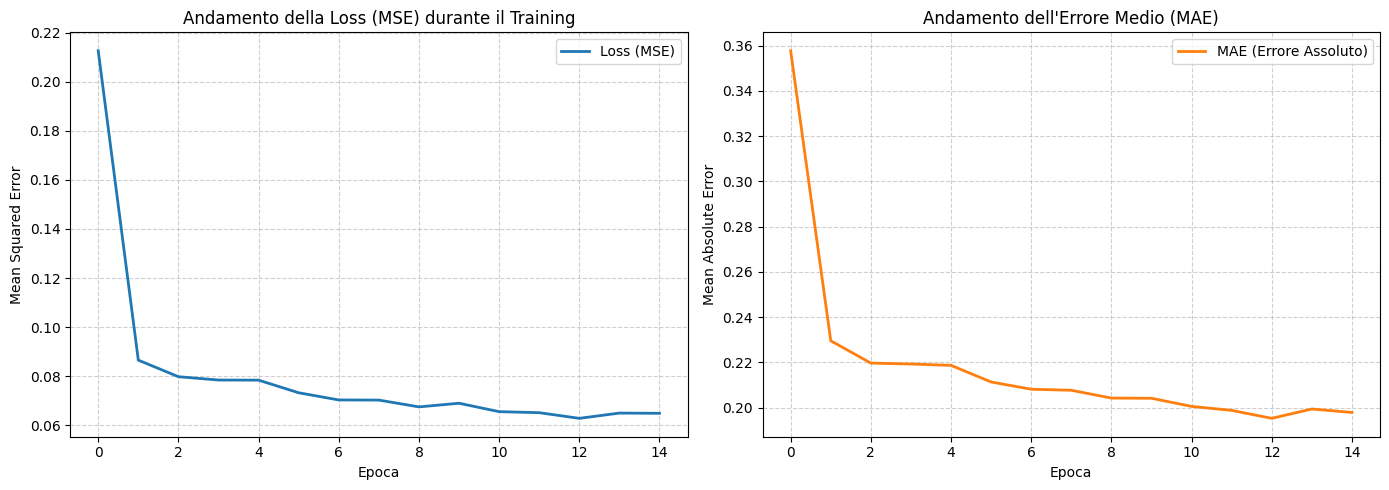

In [ ]:
# 6. Tracciamento dei Grafici
plt.figure(figsize=(14, 5))

# Grafico 1: Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss (MSE)', color='#1f77b4', linewidth=2)
plt.title('Andamento della Loss (MSE) durante il Training')
plt.xlabel('Epoca')
plt.ylabel('Mean Squared Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Grafico 2: Metrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE (Errore Assoluto)', color='#ff7f0e', linewidth=2)
plt.title('Andamento dell\'Errore Medio (MAE)')
plt.xlabel('Epoca')
plt.ylabel('Mean Absolute Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# PREVISIONE
# Carichiamo il file di TEST di Kaggle esattamente come per il train
test_csv_path = os.path.join(path, "DailyDelhiClimateTest.csv")
df_test = pd.read_csv(test_csv_path)

# Estraiamo il valore REALE della prima riga del Test Set (meantemp è la colonna 0)
temperatura_reale_giorno1 = df_test.iloc[0]['meantemp']
data_giorno1 = df_test.iloc[0]['date']

print(data_giorno1)
print(temperatura_reale_giorno1)

2017-01-01
15.91304347826087


In [ ]:
## 3. PREPARAZIONE DEL TEST
# Prendiamo gli ultimi 7 giorni dal Train
ultimi_7_giorni = X_train_raw[-WINDOW_SIZE:]

# Trasformiamo l'input con scaler_X
ultimi_7_giorni_scaled = scaler_X.transform(ultimi_7_giorni)

# Creiamo la forma 3D per Keras: (1, 7, 4)
input_3d = np.expand_dims(ultimi_7_giorni_scaled, axis=0)

# 4. Predizione
predizione_scaled = model.predict(input_3d, verbose=0) # verbose=0 rimuove il log dello step

# Invertiamo la normalizzazione direttamente con lo scaler del Target
predizione_celsius = scaler_y.inverse_transform(predizione_scaled)[0, 0]

# 5. CONFRONTO
df_test = pd.read_csv(test_csv_path)
temperatura_reale = df_test.iloc[0]['meantemp']

print("=" * 55)
print(f"Data del Test:        {df_test.iloc[0]['date']}")
print(f"Temperatura REALE:    {temperatura_reale:.2f} °C")
print(f"Temperatura PREVISTA: {predizione_celsius:.2f} °C")
print(f"Errore commesso:      {abs(predizione_celsius - temperatura_reale):.2f} °C")
print("=" * 55)

📅 Data del Test:        2017-01-01
🎯 Temperatura REALE:    15.91 °C
🤖 Temperatura PREVISTA: 13.91 °C
📏 Errore commesso:      2.00 °C
